# Evaluation: Conditional GAN vs Diffusion on Fashion-MNIST

This notebook evaluates the quality, diversity, and conditioning accuracy of:
- **GAN (stabilized)** with embed_dim=32 (trained with gradient penalty)
- **GAN ablation models** with embed_dim in {8, 16, 32, 64, 256}
- **Diffusion model** with EMA, cosine schedule, and classifier-free guidance

All metrics are computed using a **Fashion-MNIST-specific feature extractor** trained from scratch, avoiding the domain mismatch of ImageNet-pretrained networks.

## 1. Setup

In [1]:
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
import torchvision
import torchvision.transforms as transforms
from torchvision.utils import make_grid, save_image
import matplotlib.pyplot as plt
import numpy as np
from tqdm.notebook import tqdm
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from scipy.linalg import sqrtm
import warnings
warnings.filterwarnings('ignore')

# Set random seeds for reproducibility
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

# Paths
MODELS_DIR = "/kaggle/working/models"
RESULTS_DIR = "/kaggle/working/results"
os.makedirs(MODELS_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)

# Dataset constants
IMG_SIZE = 28
CHANNELS = 1
NUM_CLASSES = 10
CLASS_NAMES = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

Device: cuda


## 2. Feature Extractor (CNN Classifier)

**Why train our own classifier?**  
Fashion-MNIST consists of 28×28 grayscale images of clothing items - a domain far from ImageNet's natural images. Using a pretrained ImageNet network would introduce irrelevant inductive biases. Instead, we train a compact CNN from scratch to extract features that are truly meaningful for this dataset.

**Architecture:**  
- 3 convolutional blocks with increasing channels (32 -> 64 -> 128)
- MaxPooling for downsampling
- Adaptive average pooling for spatial invariance
- Final fully-connected layer for classification

The features from the penultimate layer are used for FID and Precision/Recall.

In [2]:
class FeatureExtractor(nn.Module):
    """
    CNN classifier for Fashion-MNIST.
    Returns features (before FC) or logits based on return_features flag.
    """
    def __init__(self, num_classes=10):
        super().__init__()
        
        self.conv_layers = nn.Sequential(
            # Block 1: 1x28x28 -> 32x14x14
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            
            # Block 2: 32x14x14 -> 64x7x7
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            
            # Block 3: 64x7x7 -> 128x7x7 (no pooling)
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
        )
        
        self.global_pool = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Linear(128, num_classes)
    
    def forward(self, x, return_features=False):
        x = self.conv_layers(x)
        x = self.global_pool(x)
        features = x.view(x.size(0), -1)  # (batch, 128)
        
        if return_features:
            return features
        
        logits = self.fc(features)
        return logits


def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


model = FeatureExtractor(NUM_CLASSES)
print(f"Feature extractor parameters: {count_parameters(model):,}")

Feature extractor parameters: 94,410


### 2.1 Data Preparation

In [3]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))  # Normalize to [-1, 1] to match GAN outputs
])

# Load full training set
full_dataset = torchvision.datasets.FashionMNIST(
    root="./data", train=True, download=True, transform=transform
)

# Split into train and validation (80/20)
train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size
train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size])

# Test set for final evaluation
test_dataset = torchvision.datasets.FashionMNIST(
    root="./data", train=False, download=True, transform=transform
)

# Data loaders
BATCH_SIZE = 128
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print(f"Train samples: {len(train_dataset)}")
print(f"Val samples: {len(val_dataset)}")
print(f"Test samples: {len(test_dataset)}")

100%|██████████| 26.4M/26.4M [00:01<00:00, 16.7MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 267kB/s]
100%|██████████| 4.42M/4.42M [00:00<00:00, 4.96MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 11.3MB/s]

Train samples: 48000
Val samples: 12000
Test samples: 10000


### 2.2 Training

In [4]:
def train_classifier(model, train_loader, val_loader, 
                                          epochs=50, lr=1e-3, patience=10):
    model = model.to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()
    
    history = {'train_loss': [], 'val_loss': [], 'val_acc': []}
    
    best_val_acc = 0
    best_model_state = None
    epochs_without_improvement = 0
    
    for epoch in range(epochs):
        # Training
        model.train()
        train_loss = 0
        for images, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}", leave=False):
            images, labels = images.to(device), labels.to(device)
            
            optimizer.zero_grad()
            logits = model(images)
            loss = criterion(logits, labels)
            loss.backward()
            optimizer.step()
            
            train_loss += loss.item()
        
        # Validation
        model.eval()
        val_loss = 0
        correct = 0
        total = 0
        
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                logits = model(images)
                loss = criterion(logits, labels)
                val_loss += loss.item()
                
                preds = logits.argmax(dim=1)
                correct += (preds == labels).sum().item()
                total += labels.size(0)
        
        avg_train_loss = train_loss / len(train_loader)
        avg_val_loss = val_loss / len(val_loader)
        val_acc = correct / total
        
        history['train_loss'].append(avg_train_loss)
        history['val_loss'].append(avg_val_loss)
        history['val_acc'].append(val_acc)
        
        # Early stopping logic
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_model_state = model.state_dict().copy()
            epochs_without_improvement = 0
            print(f"Epoch {epoch+1}: New best val_acc={val_acc:.4f}")
        else:
            epochs_without_improvement += 1
        
        if (epoch + 1) % 10 == 0:
            print(f"Epoch {epoch+1}: train_loss={avg_train_loss:.4f}, val_loss={avg_val_loss:.4f}, val_acc={val_acc:.4f}")
        
        # Stop if no improvement for 'patience' epochs
        if epochs_without_improvement >= patience:
            print(f"Early stopping at epoch {epoch+1}")
            break
    
    # Load best model
    model.load_state_dict(best_model_state)
    
    return model, history


model, history = train_classifier(
    FeatureExtractor(NUM_CLASSES), 
    train_loader, 
    val_loader, 
    epochs=50, 
    lr=1e-3, 
    patience=10
)

Epoch 1/50:   0%|          | 0/375 [00:00<?, ?it/s]

Epoch 1: New best val_acc=0.7725


Epoch 2/50:   0%|          | 0/375 [00:00<?, ?it/s]

Epoch 2: New best val_acc=0.8270


Epoch 3/50:   0%|          | 0/375 [00:00<?, ?it/s]

...

Epoch 26/50:   0%|          | 0/375 [00:00<?, ?it/s]

Epoch 27/50:   0%|          | 0/375 [00:00<?, ?it/s]

Epoch 28/50:   0%|          | 0/375 [00:00<?, ?it/s]

Epoch 29/50:   0%|          | 0/375 [00:00<?, ?it/s]

Early stopping at epoch 29


In [5]:
# def train_classifier(model, train_loader, val_loader, epochs=50, lr=1e-3):
#     model = model.to(device)
#     optimizer = optim.Adam(model.parameters(), lr=lr)
#     criterion = nn.CrossEntropyLoss()
    
#     history = {'train_loss': [], 'val_loss': [], 'val_acc': []}
    
#     for epoch in range(epochs):
#         # Training
#         model.train()
#         train_loss = 0
#         for images, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}", leave=False):
#             images, labels = images.to(device), labels.to(device)
            
#             optimizer.zero_grad()
#             logits = model(images)
#             loss = criterion(logits, labels)
#             loss.backward()
#             optimizer.step()
            
#             train_loss += loss.item()
        
#         # Validation
#         model.eval()
#         val_loss = 0
#         correct = 0
#         total = 0
        
#         with torch.no_grad():
#             for images, labels in val_loader:
#                 images, labels = images.to(device), labels.to(device)
#                 logits = model(images)
#                 loss = criterion(logits, labels)
#                 val_loss += loss.item()
                
#                 preds = logits.argmax(dim=1)
#                 correct += (preds == labels).sum().item()
#                 total += labels.size(0)
        
#         avg_train_loss = train_loss / len(train_loader)
#         avg_val_loss = val_loss / len(val_loader)
#         val_acc = correct / total
        
#         history['train_loss'].append(avg_train_loss)
#         history['val_loss'].append(avg_val_loss)
#         history['val_acc'].append(val_acc)
        
#         if (epoch + 1) % 10 == 0:
#             print(f"Epoch {epoch+1}: train_loss={avg_train_loss:.4f}, val_loss={avg_val_loss:.4f}, val_acc={val_acc:.4f}")
    
#     return model, history


# # Train
# print("Training feature extractor...")
# model, history = train_classifier(FeatureExtractor(NUM_CLASSES), train_loader, val_loader, epochs=50)

# # Save model
# torch.save(model.state_dict(), os.path.join(MODELS_DIR, "classifier_fmnist.pth"))
# print(f"Saved classifier to {MODELS_DIR}/classifier_fmnist.pth")

### 2.3 Evaluation on Test Set

Test Accuracy: 0.8543 (85.43%)


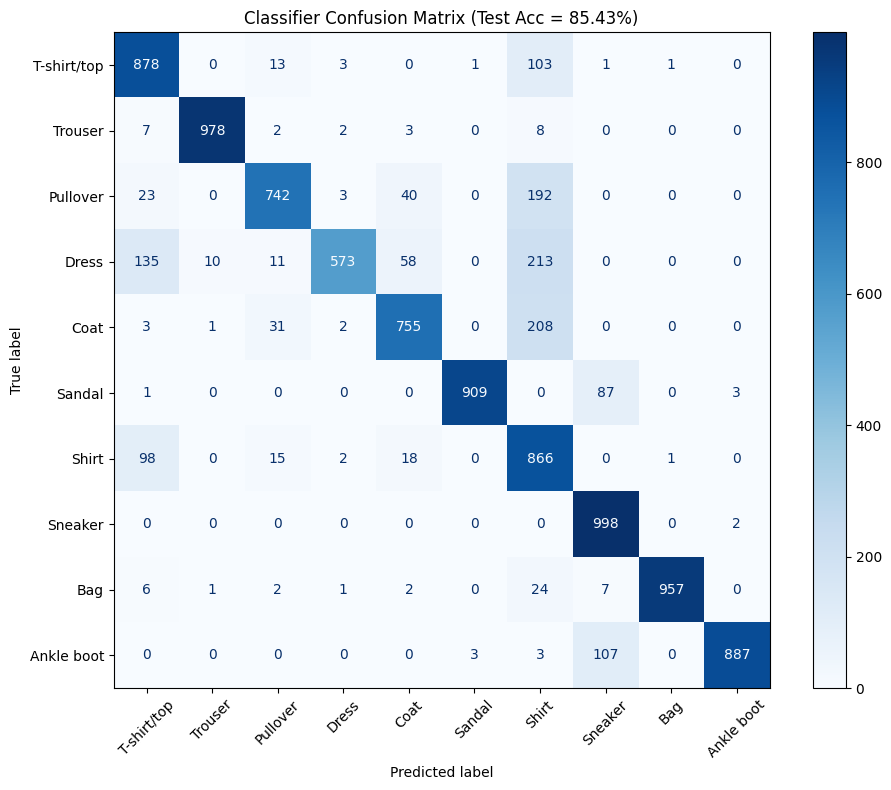

In [6]:
def evaluate_on_test(model, test_loader):
    model.eval()
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            logits = model(images)
            preds = logits.argmax(dim=1)
            
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    
    acc = accuracy_score(all_labels, all_preds)
    cm = confusion_matrix(all_labels, all_preds)
    
    return acc, cm

test_acc, test_cm = evaluate_on_test(model, test_loader)
print(f"Test Accuracy: {test_acc:.4f} ({test_acc*100:.2f}%)")

# Plot confusion matrix
fig, ax = plt.subplots(figsize=(10, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=test_cm, display_labels=CLASS_NAMES)
disp.plot(ax=ax, cmap='Blues', xticks_rotation=45)
plt.title(f"Classifier Confusion Matrix (Test Acc = {test_acc:.2%})")
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "classifier_confusion_matrix.png"), dpi=150)
plt.show()

In [7]:
@torch.no_grad()
def extract_real_features(classifier, data_loader, num_samples=5000):
    """Extract features from real images using trained classifier"""
    classifier.eval()
    all_features = []
    all_labels = []
    
    samples_needed = num_samples
    samples_collected = 0
    
    for images, labels in data_loader:
        if samples_collected >= samples_needed:
            break
        
        images = images.to(device)
        features = classifier(images, return_features=True)
        
        all_features.append(features.cpu().numpy())
        all_labels.append(labels.numpy())
        
        samples_collected += len(images)
    
    features = np.concatenate(all_features, axis=0)[:num_samples]
    labels = np.concatenate(all_labels, axis=0)[:num_samples]
    
    return features, labels


# Extract real features from test set
test_loader_real = DataLoader(test_dataset, batch_size=128, shuffle=False, num_workers=2)
real_features, real_labels = extract_real_features(model, test_loader_real, num_samples=5000)

print(f"Real features shape: {real_features.shape}")
print(f"Real labels shape: {real_labels.shape}")

# Save for later use
np.save(os.path.join(RESULTS_DIR, "real_features.npy"), real_features)
np.save(os.path.join(RESULTS_DIR, "real_labels.npy"), real_labels)

Real features shape: (5000, 128)
Real labels shape: (5000,)


### 2.4 Visualization: Training Curves

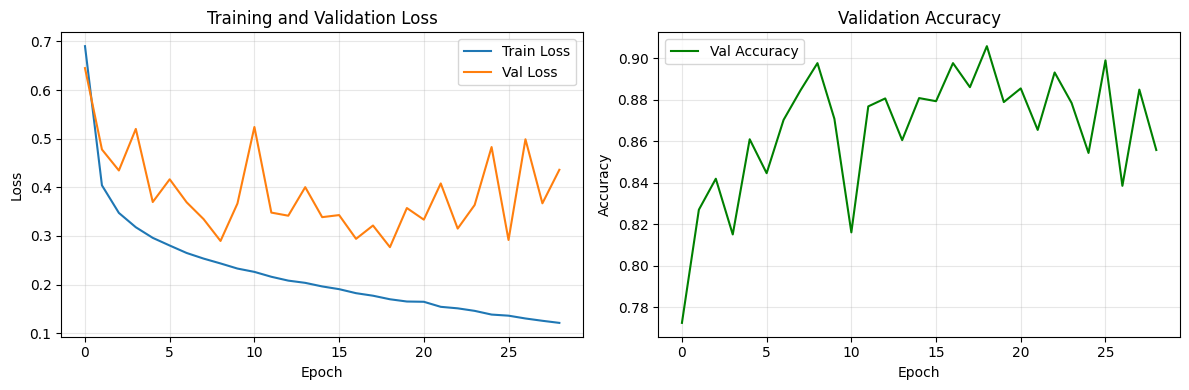

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Loss curves
axes[0].plot(history['train_loss'], label='Train Loss', linewidth=1.5)
axes[0].plot(history['val_loss'], label='Val Loss', linewidth=1.5)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training and Validation Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy curve
axes[1].plot(history['val_acc'], label='Val Accuracy', color='green', linewidth=1.5)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Validation Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "classifier_training_curves.png"), dpi=150)
plt.show()

## 3. GAN Ablation Models

**Goal:** Analyze how the label embedding dimension affects mode coverage and sample diversity.

**Models:** Trained separately using `ConditionalGanStabilization.ipynb` with different `embed_dim` values:
- embed_dim = 8, 16, 32, 64, 256

All models share identical architecture (z_dim=256) and training protocol (gradient penalty, 30 epochs).

In [9]:
class Generator(nn.Module):
    """Conditional Generator for Fashion-MNIST (Baseline)"""
    def __init__(self, z_dim=100, num_classes=10, img_size=28, channels=1, embed_dim=32):
        super().__init__()
        self.label_emb = nn.Embedding(num_classes, embed_dim)
        self.init_size = img_size // 4  # 7 for 28x28 images
        
        self.l1 = nn.Sequential(
            nn.Linear(z_dim + embed_dim, 128 * self.init_size ** 2),
            nn.BatchNorm1d(128 * self.init_size ** 2),
            nn.ReLU(inplace=True),
        )
        
        self.conv_blocks = nn.Sequential(
            nn.ConvTranspose2d(128, 64, 4, stride=2, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.ConvTranspose2d(64, channels, 4, stride=2, padding=1),
            nn.Tanh(),
        )
    
    def forward(self, z, labels):
        label_emb = self.label_emb(labels)
        gen_input = torch.cat((z, label_emb), dim=1)
        out = self.l1(gen_input)
        out = out.view(out.size(0), 128, self.init_size, self.init_size)
        return self.conv_blocks(out)

In [10]:
# Define paths for each ablation model
EMBED_DIMS = [8, 16, 32, 64, 256]
Z_DIM = 256

gan_models = {}  # store trainers for each embed_dim

for embed_dim in EMBED_DIMS:
    model_path = os.path.join("/kaggle/input/models/meldilen/gans-and-diffusions/other/default/2", f"gan_embed{embed_dim}_g.pth")
    
    if os.path.exists(model_path):
        # Create generator with correct embed_dim
        G = Generator(z_dim=Z_DIM, num_classes=NUM_CLASSES, 
                      img_size=IMG_SIZE, channels=CHANNELS, 
                      embed_dim=embed_dim).to(device)
        G.load_state_dict(torch.load(model_path, map_location=device))
        G.eval()
        
        gan_models[embed_dim] = G
        print(f"Loaded: embed_dim={embed_dim} from {model_path}")
    else:
        print(f"WARNING: {model_path} not found. Skipping embed_dim={embed_dim}")

print(f"\nLoaded {len(gan_models)} GAN models")

Loaded: embed_dim=8 from /kaggle/input/models/meldilen/gans-and-diffusions/other/default/2/gan_embed8_g.pth
Loaded: embed_dim=16 from /kaggle/input/models/meldilen/gans-and-diffusions/other/default/2/gan_embed16_g.pth
Loaded: embed_dim=32 from /kaggle/input/models/meldilen/gans-and-diffusions/other/default/2/gan_embed32_g.pth
Loaded: embed_dim=64 from /kaggle/input/models/meldilen/gans-and-diffusions/other/default/2/gan_embed64_g.pth
Loaded: embed_dim=256 from /kaggle/input/models/meldilen/gans-and-diffusions/other/default/2/gan_embed256_g.pth

Loaded 5 GAN models


In [11]:
# Also load the original fixed GAN (embed_dim=32, trained with gradient penalty)
gan_fixed_path = "/kaggle/input/models/meldilen/gans-and-diffusions/other/default/2/gan_generator_best.pth"

if os.path.exists(gan_fixed_path):
    G_fixed = Generator(z_dim=Z_DIM, num_classes=NUM_CLASSES,
                        img_size=IMG_SIZE, channels=CHANNELS,
                        embed_dim=32).to(device)
    G_fixed.load_state_dict(torch.load(gan_fixed_path, map_location=device))
    G_fixed.eval()
    print(f"Loaded GAN fixed (embed_dim=32) from {gan_fixed_path}")
else:
    print(f"WARNING: {gan_fixed_path} not found")
    G_fixed = None

Loaded GAN fixed (embed_dim=32) from /kaggle/input/models/meldilen/gans-and-diffusions/other/default/2/gan_generator_best.pth


## 4. Load Diffusion Model

**Model:** Conditional diffusion model trained in `ConditionalDiffusionImproved.ipynb` with:
- EMA (exponential moving average) weights
- Cosine noise schedule
- Classifier-free guidance (CFG) with label dropout
- DDIM sampling support

The checkpoint contains both model weights and diffusion parameters.

### 4.1 Define Diffusion Model Architecture

We need to define the same U-Net architecture used during training.

In [12]:
diffusion_path = "/kaggle/input/models/meldilen/gans-and-diffusions/other/default/2/conditional_diffusion_30epochs.pt"

import math
from einops import rearrange, reduce, repeat
from einops.layers.torch import Rearrange

# Helper classes for diffusion model
class SinusoidalPosEmb(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.dim = dim

    def forward(self, x):
        device = x.device
        half_dim = self.dim // 2
        emb = math.log(10000) / (half_dim - 1)
        emb = torch.exp(torch.arange(half_dim, device=device) * -emb)
        emb = x[:, None] * emb[None, :]
        emb = torch.cat((emb.sin(), emb.cos()), dim=-1)
        return emb


class LayerNorm(nn.Module):
    def __init__(self, dim, eps=1e-5):
        super().__init__()
        self.eps = eps
        self.g = nn.Parameter(torch.ones(1, dim, 1, 1))
        self.b = nn.Parameter(torch.zeros(1, dim, 1, 1))

    def forward(self, x):
        var = torch.var(x, dim=1, unbiased=False, keepdim=True)
        mean = torch.mean(x, dim=1, keepdim=True)
        return (x - mean) / (var + self.eps).sqrt() * self.g + self.b


class Upsample(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.conv = nn.Conv2d(dim, dim, 3, padding=1)

    def forward(self, x):
        x = F.interpolate(x, scale_factor=2.0, mode="nearest")
        return self.conv(x)


def Downsample(dim):
    return nn.Conv2d(dim, dim, 4, 2, 1)


class ConvBlock(nn.Sequential):
    def __init__(self, in_channel, out_channel, kern_size, padd, groups, downsample=True, use_act=True):
        super().__init__()
        self.add_module(
            "conv",
            nn.Conv2d(
                in_channel,
                out_channel,
                kern_size,
                stride=2 if downsample else 1,
                padding=padd,
                groups=groups,
            ),
        )
        self.add_module("norm", nn.GroupNorm(groups, out_channel))
        self.add_module("act", nn.SiLU() if use_act else nn.Identity())


class ResnetBlock(nn.Module):
    def __init__(self, in_channels, out_channels, *, time_emb_dim=None, groups=8, downsample=False):
        super().__init__()
        self.mlp = (
            nn.Sequential(nn.SiLU(), nn.Linear(time_emb_dim, out_channels))
            if time_emb_dim is not None
            else None
        )

        self.block1 = ConvBlock(in_channels, out_channels, 3, 1, groups, downsample=downsample)
        self.block2 = ConvBlock(out_channels, out_channels, 3, 1, groups, downsample=False, use_act=False)

        if in_channels != out_channels or downsample:
            self.res_conv = nn.Conv2d(
                in_channels, out_channels, kernel_size=1, stride=2 if downsample else 1
            )
        else:
            self.res_conv = nn.Identity()
        self.act = nn.SiLU()

    def forward(self, x, time_emb=None):
        res = self.res_conv(x)

        h = self.block1(x)
        if self.mlp is not None and time_emb is not None:
            time_emb = self.mlp(time_emb)
            h = h + time_emb[:, :, None, None]
        h = self.act(h)
        h = self.block2(h)

        return h + res


class Attention(nn.Module):
    def __init__(self, dim, heads=4, dim_head=32):
        super().__init__()
        self.scale = dim_head ** -0.5
        self.heads = heads
        hidden_dim = dim_head * heads
        self.to_qkv = nn.Conv2d(dim, hidden_dim * 3, 1, bias=False)
        self.to_out = nn.Conv2d(hidden_dim, dim, 1)

    def forward(self, x):
        b, c, h, w = x.shape
        qkv = self.to_qkv(x).chunk(3, dim=1)
        q, k, v = map(lambda t: rearrange(t, "b (h c) x y -> b h c (x y)", h=self.heads), qkv)
        sim = torch.einsum("b h d i, b h d j -> b h i j", q, k) * self.scale
        sim = sim - sim.amax(dim=-1, keepdim=True).detach()
        attn = sim.softmax(dim=-1)
        out = torch.einsum("b h i j, b h d j -> b h i d", attn, v)
        out = rearrange(out, "b h (x y) d -> b (h d) x y", x=h, y=w)
        return self.to_out(out)


class LinearAttention(nn.Module):
    def __init__(self, dim, heads=4, dim_head=32):
        super().__init__()
        self.scale = dim_head ** -0.5
        self.heads = heads
        hidden_dim = dim_head * heads
        self.to_qkv = nn.Conv2d(dim, hidden_dim * 3, 1, bias=False)
        self.to_out = nn.Sequential(nn.Conv2d(hidden_dim, dim, 1), LayerNorm(dim))

    def forward(self, x):
        b, c, h, w = x.shape
        qkv = self.to_qkv(x).chunk(3, dim=1)
        q, k, v = map(lambda t: rearrange(t, "b (h c) x y -> b h c (x y)", h=self.heads), qkv)

        q = q.softmax(dim=-2)
        k = k.softmax(dim=-1)

        q = q * self.scale
        context = torch.einsum("b h d n, b h e n -> b h d e", k, v)

        out = torch.einsum("b h d e, b h d n -> b h e n", context, q)
        out = rearrange(out, "b h c (x y) -> b (h c) x y", h=self.heads, x=h, y=w)
        return self.to_out(out)


class Unet(nn.Module):
    def __init__(self, num_classes=10, null_label=10):
        super().__init__()
        self.null_label = null_label

        time_dim = 32 * 4
        self.time_mlp = nn.Sequential(
            SinusoidalPosEmb(32),
            nn.Linear(32, time_dim),
            nn.GELU(),
            nn.Linear(time_dim, time_dim),
        )

        self.init_conv = nn.Conv2d(1, 32, kernel_size=1)

        self.down1 = ResnetBlock(32, 64, time_emb_dim=time_dim, downsample=True)
        self.attn1 = LinearAttention(64)
        self.down2 = ResnetBlock(64, 128, time_emb_dim=time_dim, downsample=True)
        self.attn2 = LinearAttention(128)
        self.down3 = ResnetBlock(128, 256, time_emb_dim=time_dim, downsample=True)
        self.attn3 = LinearAttention(256)

        self.bottleneck = ResnetBlock(256, 512, time_emb_dim=time_dim, downsample=False)
        self.attn_bottle = Attention(512)

        self.upsample1_op = Upsample(512)
        self.up1 = ResnetBlock(512 + 128, 256, time_emb_dim=time_dim, downsample=False)

        self.upsample2_op = Upsample(256)
        self.up2 = ResnetBlock(256 + 64, 128, time_emb_dim=time_dim, downsample=False)

        self.upsample3_op = Upsample(128)
        self.up3 = ResnetBlock(128 + 32, 64, time_emb_dim=time_dim, downsample=False)

        self.final_res = ResnetBlock(64, 32, time_emb_dim=time_dim, downsample=False)
        self.final_conv = nn.Conv2d(32, 1, 1)

        self.label_emb = nn.Embedding(num_classes + 1, time_dim)

    def forward(self, x, t, y):
        t_emb = self.time_mlp(t.float())
        t_emb = t_emb + self.label_emb(y)

        x_initial_conv_out = self.init_conv(x)
        h = x_initial_conv_out

        h_skip_14x14 = self.down1(h, t_emb)
        h = self.attn1(h_skip_14x14)

        h_skip_7x7 = self.down2(h, t_emb)
        h = self.attn2(h_skip_7x7)

        h_skip_4x4 = self.down3(h, t_emb)
        h = self.attn3(h_skip_4x4)

        h = self.bottleneck(h, t_emb)
        h = self.attn_bottle(h)

        h = self.upsample1_op(h)
        h = F.interpolate(h, size=h_skip_7x7.shape[-2:], mode="nearest")
        h = torch.cat([h, h_skip_7x7], dim=1)
        h = self.up1(h, t_emb)

        h = self.upsample2_op(h)
        h = F.interpolate(h, size=h_skip_14x14.shape[-2:], mode="nearest")
        h = torch.cat([h, h_skip_14x14], dim=1)
        h = self.up2(h, t_emb)

        h = self.upsample3_op(h)
        h = F.interpolate(h, size=x_initial_conv_out.shape[-2:], mode="nearest")
        h = torch.cat([h, x_initial_conv_out], dim=1)
        h = self.up3(h, t_emb)

        h = self.final_res(h, t_emb)
        return self.final_conv(h)

### 4.2 Define Diffusion Process (ImprovedDiffusion)

Recreate the diffusion process with the same parameters used during training.

In [13]:
def cosine_beta_schedule(timesteps, s=0.008):
    steps = timesteps + 1
    x = torch.linspace(0, timesteps, steps)
    alphas_cumprod = torch.cos(((x / timesteps) + s) / (1 + s) * math.pi * 0.5) ** 2
    alphas_cumprod = alphas_cumprod / alphas_cumprod[0]
    betas = 1.0 - (alphas_cumprod[1:] / alphas_cumprod[:-1])
    return torch.clip(betas, 1e-5, 0.999)


class ImprovedDiffusion:
    def __init__(self, num_timesteps, img_shape, device, min_snr_gamma=5.0, uniform_loss_weights=True):
        self.num_timesteps = num_timesteps
        self.img_shape = img_shape
        self.device = device
        self.min_snr_gamma = min_snr_gamma
        self.uniform_loss_weights = uniform_loss_weights

        betas = cosine_beta_schedule(num_timesteps)
        self.betas = betas.to(device)
        self.alphas = 1.0 - self.betas
        self.alphas_cumprod = torch.cumprod(self.alphas, dim=0)
        self.alphas_cumprod_prev = F.pad(self.alphas_cumprod[:-1], (1, 0), value=1.0)

    def _predict_eps_cfg(self, model, x, t, labels, guidance_scale, null_label):
        if guidance_scale == 1.0:
            return model(x, t, labels)
        uncond = torch.full_like(labels, null_label)
        eps_c = model(x, t, labels)
        eps_u = model(x, t, uncond)
        return eps_u + guidance_scale * (eps_c - eps_u)

    def predict_x0_from_eps(self, x, t, eps):
        ab = self.alphas_cumprod[t][:, None, None, None]
        return (x - (1.0 - ab).sqrt() * eps) / ab.sqrt().clamp(min=1e-8)

    @torch.no_grad()
    def sample_ddim(self, model, n, labels, steps=100, guidance_scale=1.0, null_label=10, eta=0.0, x_start=None):
        model.eval()
        if x_start is not None:
            x = x_start.to(self.device)
        else:
            x = torch.randn(n, *self.img_shape, device=self.device)
        
        ts = torch.linspace(0, self.num_timesteps - 1, steps, device=self.device).long()
        ts = torch.unique(ts).sort(descending=True).values
        ts_next = torch.cat([ts[1:], torch.tensor([-1], device=self.device)])

        for t_now, t_next in zip(ts.tolist(), ts_next.tolist()):
            t_b = torch.full((n,), t_now, device=self.device, dtype=torch.long)
            ab = self.alphas_cumprod[t_now]
            ab_next = self.alphas_cumprod[t_next] if t_next >= 0 else torch.ones((), device=self.device)

            eps = self._predict_eps_cfg(model, x, t_b, labels, guidance_scale, null_label)
            pred_x0 = self.predict_x0_from_eps(x, t_b, eps).clamp(-1, 1)

            if t_next < 0:
                x = pred_x0
                break

            sigma = eta * ((1.0 - ab_next) / (1.0 - ab).clamp(min=1e-9) * (1.0 - ab / ab_next.clamp(min=1e-9))).sqrt()
            c1 = ab_next.sqrt()
            c2 = ((1.0 - ab_next) - sigma ** 2).clamp(min=0).sqrt()
            noise = torch.randn_like(x) if eta > 0 else 0.0
            x = c1 * pred_x0 + c2 * eps + sigma * noise

        model.train()
        x = (x.clamp(-1, 1) + 1) / 2
        return (x * 255).type(torch.uint8)

### 4.3 Load Diffusion Model Weights

In [14]:
NULL_LABEL = 10
IMG_SHAPE = (1, 28, 28)
NUM_TIMESTEPS = 1000

if os.path.exists(diffusion_path):
    checkpoint = torch.load(diffusion_path, map_location=device)
    
    # Initialize model
    diffusion_model = Unet(num_classes=NUM_CLASSES, null_label=NULL_LABEL).to(device)
    
    # Load EMA weights
    if 'ema_shadow_state_dict' in checkpoint:
        diffusion_model.load_state_dict(checkpoint['ema_shadow_state_dict'])
        print("Loaded EMA weights")
    else:
        diffusion_model.load_state_dict(checkpoint['model_state_dict'])
        print("Loaded model weights (non-EMA)")
    
    diffusion_model.eval()
    
    # Initialize diffusion process
    diffusion = ImprovedDiffusion(
        num_timesteps=NUM_TIMESTEPS,
        img_shape=IMG_SHAPE,
        device=device,
        min_snr_gamma=checkpoint.get('min_snr_gamma', 5.0),
        uniform_loss_weights=checkpoint.get('uniform_loss_weights', True)
    )
    
    print(f"Diffusion model loaded successfully")
    print(f"  - Timesteps: {diffusion.num_timesteps}")
    print(f"  - Uniform loss weights: {diffusion.uniform_loss_weights}")
else:
    diffusion_model = None
    diffusion = None
    print("Diffusion model not found. Skipping.")

Loaded EMA weights
Diffusion model loaded successfully
  - Timesteps: 1000
  - Uniform loss weights: True


## 5. Generate Samples for Evaluation

For each model, we generate **5000 samples** (500 per class) to ensure stable metric computation.

**Generation parameters:**
- GAN models: 500 samples per class, z_dim=256, random noise per sample
- Diffusion model: 500 samples per class, DDIM with 100 steps, guidance_scale=1.0

**Output:** Features extracted from trained classifier for FID, Precision, Recall, and Conditional Accuracy.

In [15]:
NUM_SAMPLES_PER_CLASS = 500
TOTAL_SAMPLES = NUM_SAMPLES_PER_CLASS * NUM_CLASSES

print(f"Generating {TOTAL_SAMPLES} samples per model ({NUM_SAMPLES_PER_CLASS} per class)")

Generating 5000 samples per model (500 per class)


### 5.1 Helper Functions for Sample Generation

In [16]:
@torch.no_grad()
def generate_gan_samples(generator, num_samples_per_class=500):
    """
    Generate balanced samples from GAN.
    
    Args:
        generator: GAN generator model
        num_samples_per_class: Number of samples to generate per class
    
    Returns:
        samples: Tensor of shape (total_samples, channels, H, W) in range [-1, 1]
        labels: Tensor of shape (total_samples,) with class labels
    """
    generator.eval()
    all_samples = []
    all_labels = []
    
    for class_idx in range(NUM_CLASSES):
        labels = torch.full((num_samples_per_class,), class_idx, device=device, dtype=torch.long)
        z = torch.randn(num_samples_per_class, Z_DIM, device=device)
        samples = generator(z, labels)
        all_samples.append(samples.cpu())
        all_labels.append(labels.cpu())
    
    samples = torch.cat(all_samples, dim=0)
    labels = torch.cat(all_labels, dim=0)
    
    return samples, labels


@torch.no_grad()
def generate_diffusion_samples(model, diffusion, num_samples_per_class=500, guidance_scale=1.0):
    """
    Generate balanced samples from Diffusion model.
    
    Args:
        model: Diffusion U-Net
        diffusion: ImprovedDiffusion instance
        num_samples_per_class: Number of samples to generate per class
        guidance_scale: CFG scale (1.0 = conditional only)
    
    Returns:
        samples: Tensor of shape (total_samples, channels, H, W) in range [-1, 1]
        labels: Tensor of shape (total_samples,) with class labels
    """
    model.eval()
    all_samples = []
    all_labels = []
    
    for class_idx in range(NUM_CLASSES):
        labels = torch.full((num_samples_per_class,), class_idx, device=device, dtype=torch.long)
        
        # DDIM sampling returns uint8 in [0, 255]
        samples_uint8 = diffusion.sample_ddim(
            model,
            num_samples_per_class,
            labels,
            steps=100,
            guidance_scale=guidance_scale,
            null_label=NULL_LABEL,
            eta=0.0
        )
        
        # Convert to float in [-1, 1] for feature extraction
        samples = (samples_uint8.float() / 127.5) - 1.0
        
        all_samples.append(samples)
        all_labels.append(labels.cpu())
    
    samples = torch.cat(all_samples, dim=0)
    labels = torch.cat(all_labels, dim=0)
    
    return samples, labels


@torch.no_grad()
def extract_features(classifier, samples, batch_size=128):
    """
    Extract features from samples using trained classifier.
    
    Args:
        classifier: FeatureExtractor model
        samples: Tensor of images in range [-1, 1]
        batch_size: Batch size for feature extraction
    
    Returns:
        features: NumPy array of shape (n_samples, feature_dim)
    """
    classifier.eval()
    all_features = []
    
    for i in range(0, len(samples), batch_size):
        batch = samples[i:i+batch_size].to(device)
        features = classifier(batch, return_features=True)
        all_features.append(features.cpu().numpy())
    
    return np.concatenate(all_features, axis=0)

### 5.2 Generate Samples for GAN Ablation Models

In [17]:
# Dictionary to store generated samples and features
gan_ablation_data = {}

for embed_dim, G in gan_models.items():
    print(f"\nGenerating samples for GAN (embed_dim={embed_dim})...")
    
    samples, labels = generate_gan_samples(G, NUM_SAMPLES_PER_CLASS)
    print(f"  Generated {len(samples)} samples")
    
    features = extract_features(model, samples)
    print(f"  Extracted features: {features.shape}")
    
    # Store
    gan_ablation_data[embed_dim] = {
        'samples': samples,
        'labels': labels,
        'features': features
    }


Generating samples for GAN (embed_dim=8)...
  Generated 5000 samples
  Extracted features: (5000, 128)

Generating samples for GAN (embed_dim=16)...
  Generated 5000 samples
  Extracted features: (5000, 128)

Generating samples for GAN (embed_dim=32)...
  Generated 5000 samples
  Extracted features: (5000, 128)

Generating samples for GAN (embed_dim=64)...
  Generated 5000 samples
  Extracted features: (5000, 128)

Generating samples for GAN (embed_dim=256)...
  Generated 5000 samples
  Extracted features: (5000, 128)


### 5.3 Generate Samples for GAN (embed_dim=32, epoch=50)

In [18]:
if G_fixed is not None:    
    samples, labels = generate_gan_samples(G_fixed, NUM_SAMPLES_PER_CLASS)
    features = extract_features(model, samples)
    
    gan_fixed_data = {
        'samples': samples,
        'labels': labels,
        'features': features
    }
    print(f"  Generated {len(samples)} samples, features shape: {features.shape}")
else:
    gan_fixed_data = None
    print("GAN Fixed not available")

  Generated 5000 samples, features shape: (5000, 128)


### 5.4 Generate Samples for Diffusion with Different Guidance Scales


Generating samples for Diffusion with different guidance scales...

  Guidance scale = 1.0
    Generated 5000 samples, features shape: (5000, 128)


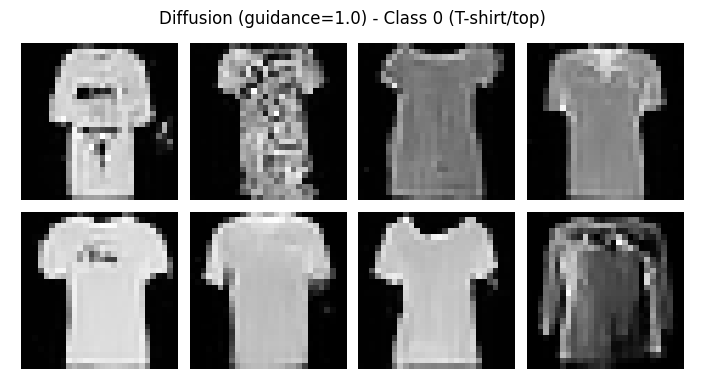


  Guidance scale = 1.5
    Generated 5000 samples, features shape: (5000, 128)


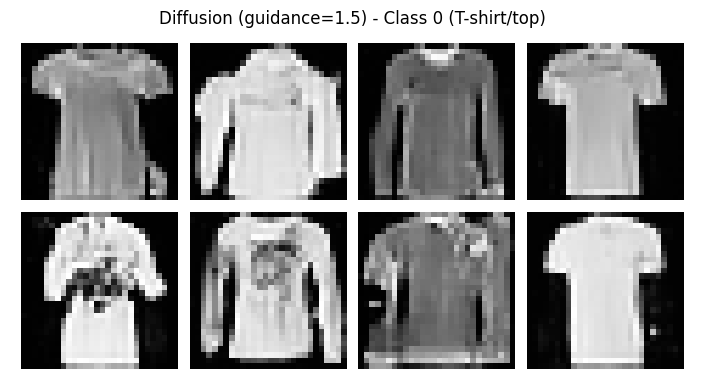


  Guidance scale = 2.0
    Generated 5000 samples, features shape: (5000, 128)


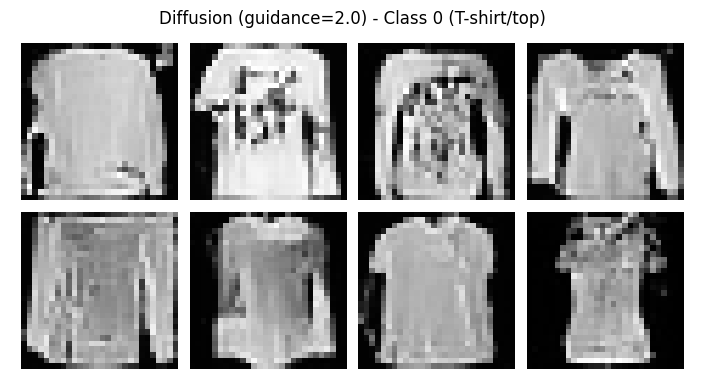


  Guidance scale = 2.5
    Generated 5000 samples, features shape: (5000, 128)


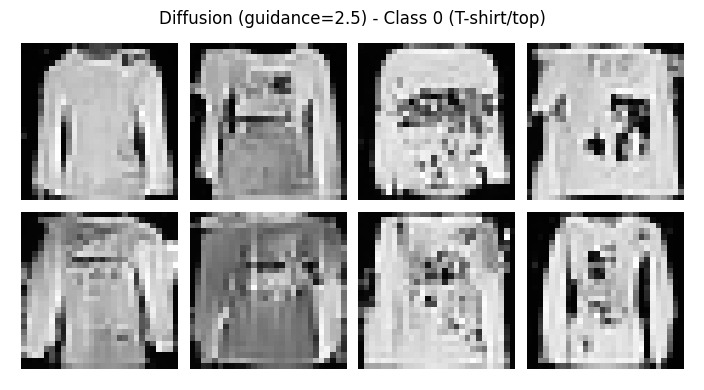


  Guidance scale = 3.0
    Generated 5000 samples, features shape: (5000, 128)


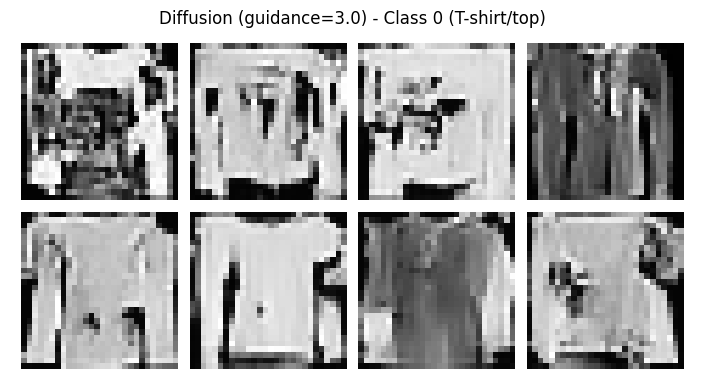

In [19]:
# Define guidance scales to test
GUIDANCE_SCALES = [1.0, 1.5, 2.0, 2.5, 3.0]

diffusion_data_by_scale = {}

if diffusion_model is not None:
    print(f"\nGenerating samples for Diffusion with different guidance scales...")
    
    for guidance_scale in GUIDANCE_SCALES:
        print(f"\n  Guidance scale = {guidance_scale}")
        
        samples, labels = generate_diffusion_samples(
            diffusion_model, diffusion, 
            NUM_SAMPLES_PER_CLASS, 
            guidance_scale=guidance_scale
        )
        
        # Extract features
        features = extract_features(model, samples)
        
        diffusion_data_by_scale[guidance_scale] = {
            'samples': samples,
            'labels': labels,
            'features': features
        }
        
        print(f"    Generated {len(samples)} samples, features shape: {features.shape}")
        
        # Quick visual check for first class
        class_0_samples = samples[labels == 0][:8]
        grid = make_grid(class_0_samples[:8], nrow=4, normalize=True, pad_value=1)
        plt.figure(figsize=(8, 4))
        plt.imshow(grid.permute(1, 2, 0).cpu().numpy(), cmap='gray')
        plt.title(f'Diffusion (guidance={guidance_scale}) - Class 0 (T-shirt/top)')
        plt.axis('off')
        plt.tight_layout()
        plt.show()
        
else:
    print("Diffusion model not available")

### 5.5 Save Generated Features to Disk

Save features to avoid recomputation when restarting the notebook.

In [20]:
# Save GAN ablation features
for embed_dim, data in gan_ablation_data.items():
    np.save(os.path.join(RESULTS_DIR, f"gan_embed{embed_dim}_features.npy"), data['features'])
    np.save(os.path.join(RESULTS_DIR, f"gan_embed{embed_dim}_labels.npy"), data['labels'])
print("GAN ablation features saved")

# Save GAN fixed features
if gan_fixed_data is not None:
    np.save(os.path.join(RESULTS_DIR, "gan_fixed_features.npy"), gan_fixed_data['features'])
    np.save(os.path.join(RESULTS_DIR, "gan_fixed_labels.npy"), gan_fixed_data['labels'])
    print("GAN fixed features saved")

# Save diffusion features
for guidance_scale, data in diffusion_data_by_scale.items():
    np.save(os.path.join(RESULTS_DIR, f"diffusion_features_{guidance_scale}.npy"), data['features'])
    np.save(os.path.join(RESULTS_DIR, f"diffusion_labels_{guidance_scale}.npy"), data['labels'])
print("Diffusion features saved")

GAN ablation features saved
GAN fixed features saved
Diffusion features saved


### 5.6 Visualize Samples

Visual quality check:


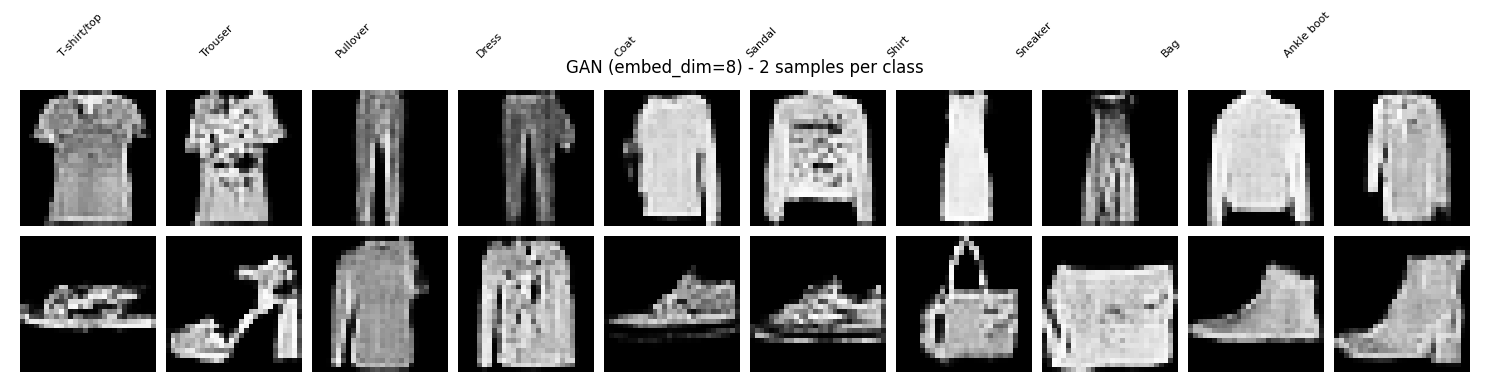

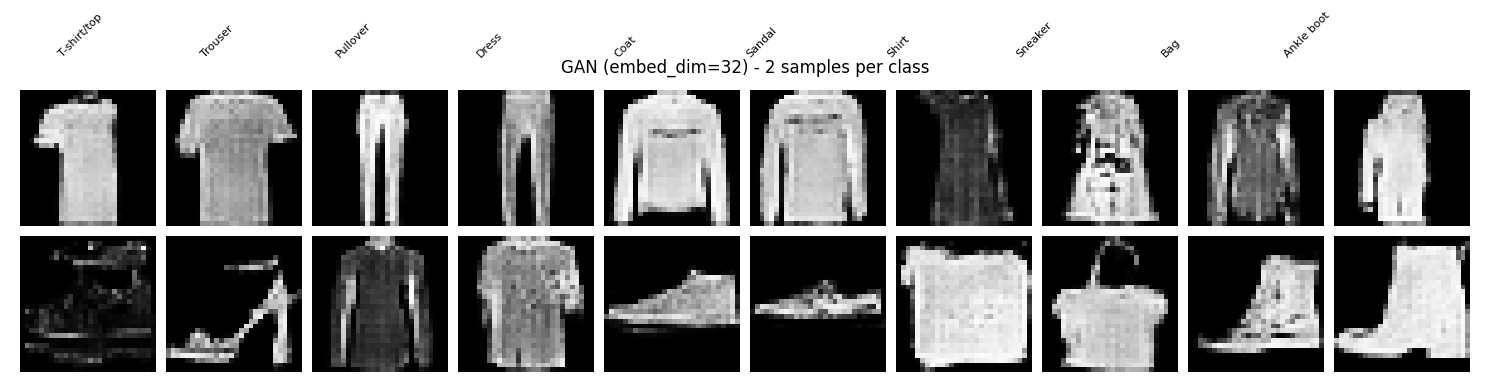

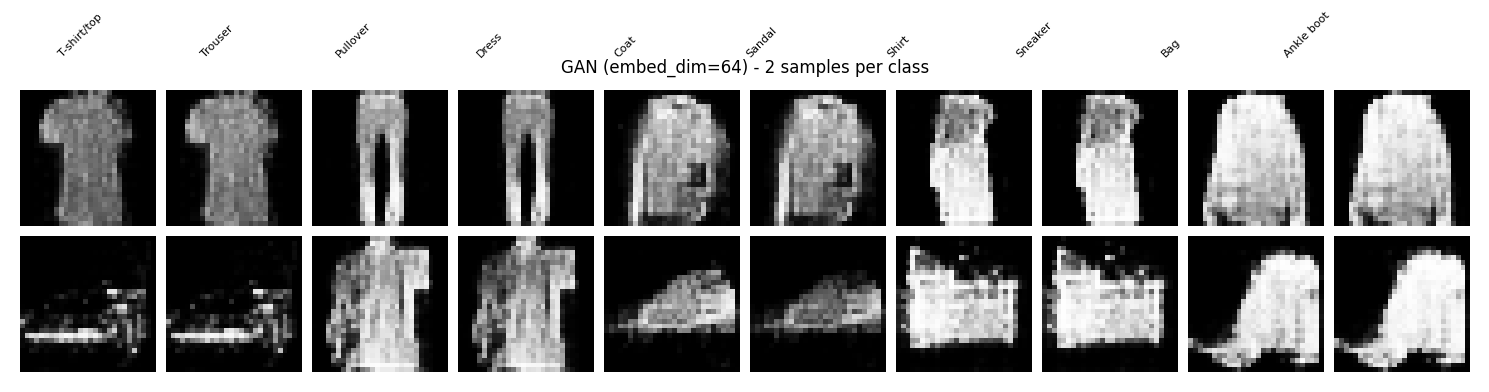

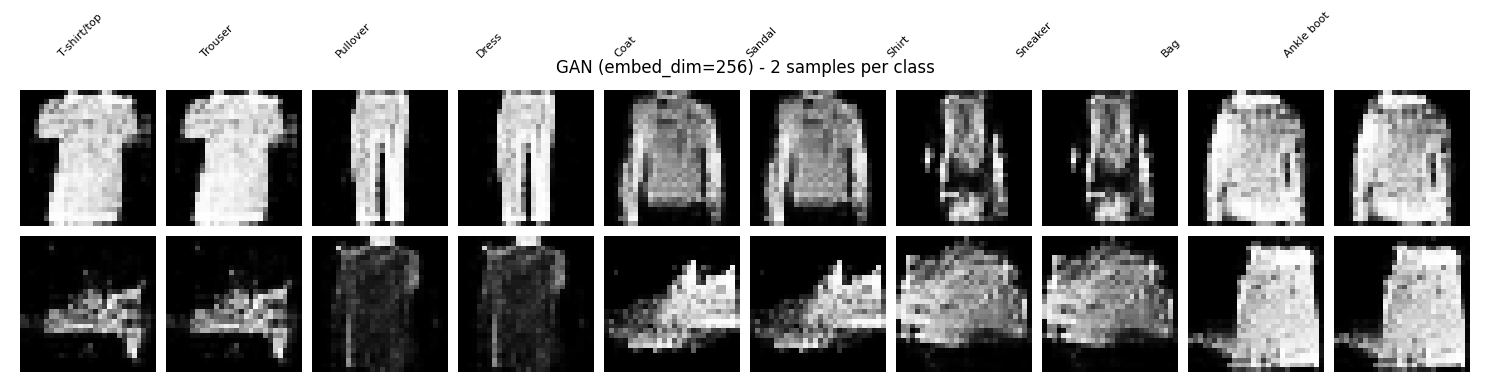

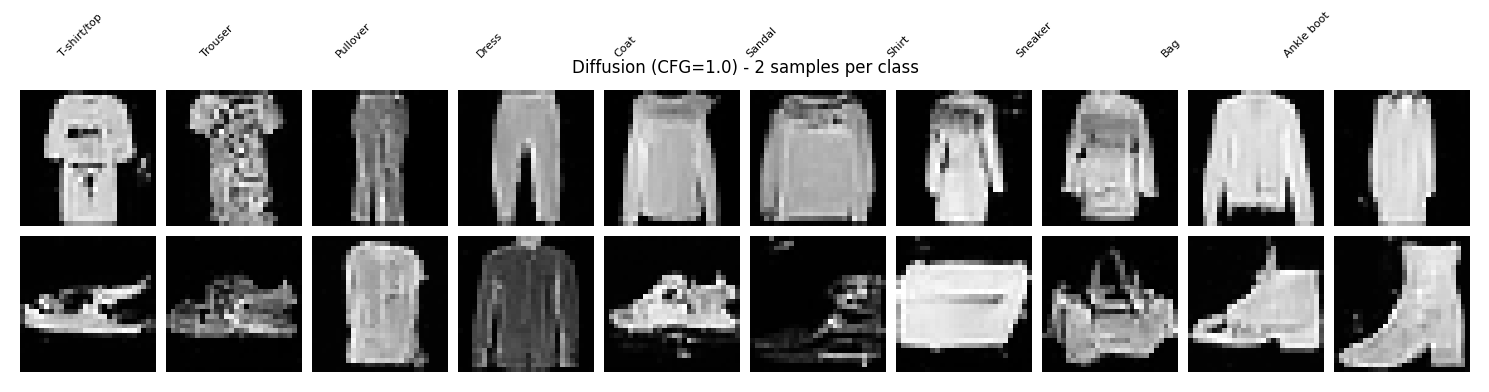

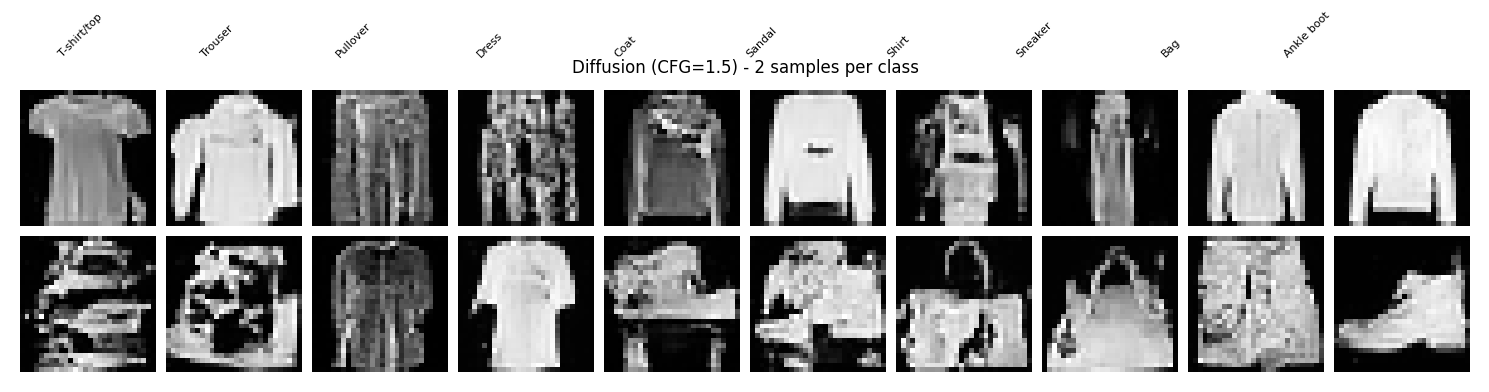

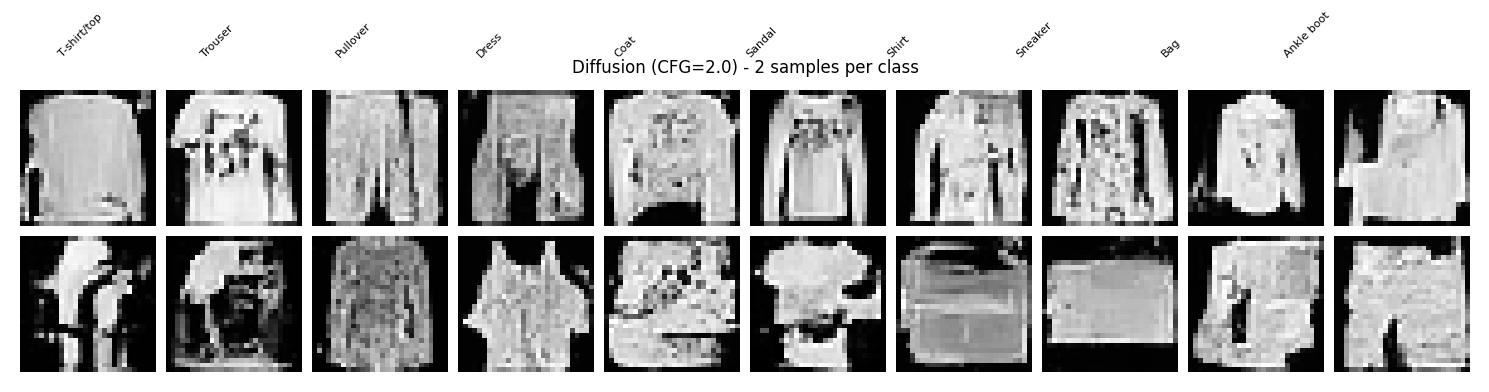

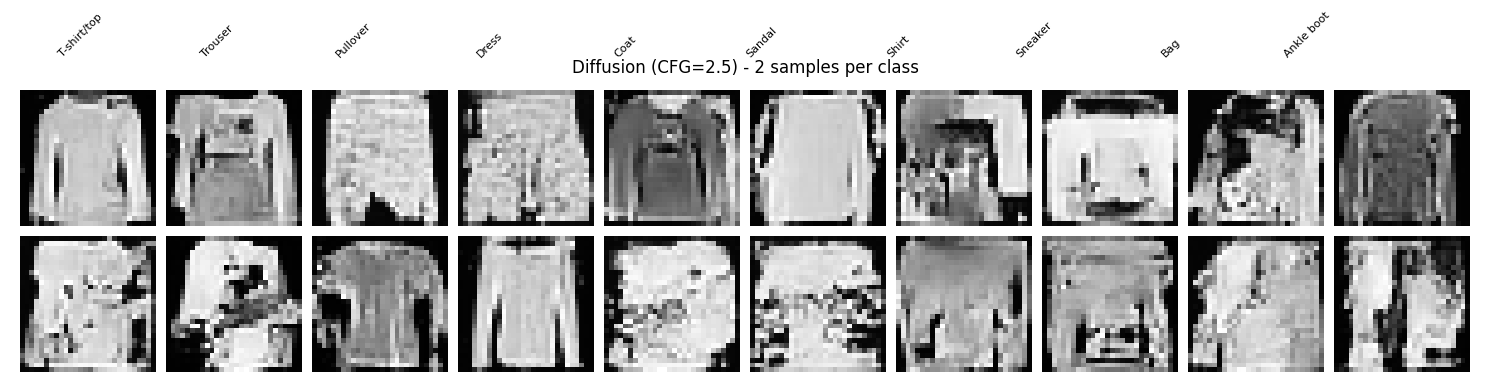

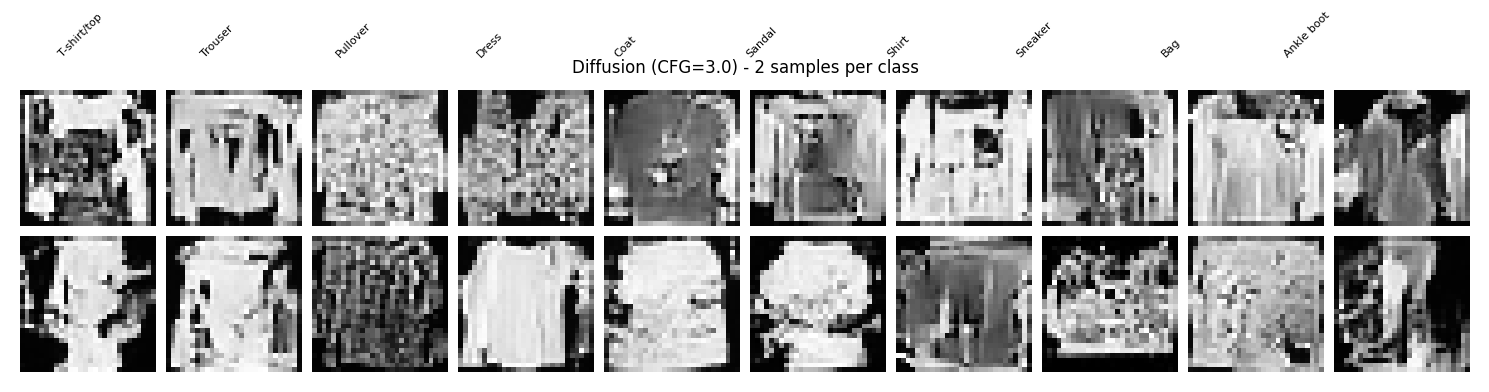

In [21]:
def display_samples_grid(samples, labels, title, num_classes=10, samples_per_class=2):
    """Display a grid of samples (2 per class)"""
    indices = []
    for c in range(num_classes):
        class_indices = torch.where(labels == c)[0][:samples_per_class]
        indices.extend(class_indices.tolist())
    
    display_samples = samples[indices]
    grid = make_grid(display_samples, nrow=num_classes, normalize=True, pad_value=1)
    
    plt.figure(figsize=(15, 4))
    plt.imshow(grid.permute(1, 2, 0).cpu().numpy(), cmap='gray')
    plt.title(title)
    plt.axis('off')
    
    # Add class labels
    for i, class_name in enumerate(CLASS_NAMES):
        plt.text(i * 28 + 14, -5, class_name, ha='center', va='bottom', fontsize=8, rotation=45)
    
    plt.tight_layout()
    plt.show()


# Display samples from selected models
print("Visual quality check:")

# GAN embed_dim=8
if 8 in gan_ablation_data:
    display_samples_grid(
        gan_ablation_data[8]['samples'], 
        gan_ablation_data[8]['labels'],
        "GAN (embed_dim=8) - 2 samples per class"
    )

# GAN embed_dim=32
if 32 in gan_ablation_data:
    display_samples_grid(
        gan_ablation_data[32]['samples'], 
        gan_ablation_data[32]['labels'],
        "GAN (embed_dim=32) - 2 samples per class"
    )

# GAN embed_dim=64
if 64 in gan_ablation_data:
    display_samples_grid(
        gan_ablation_data[64]['samples'], 
        gan_ablation_data[64]['labels'],
        "GAN (embed_dim=64) - 2 samples per class"
    )


# GAN embed_dim=256
if 256 in gan_ablation_data:
    display_samples_grid(
        gan_ablation_data[256]['samples'], 
        gan_ablation_data[256]['labels'],
        "GAN (embed_dim=256) - 2 samples per class"
    )

# Diffusions
if 1.0 in diffusion_data_by_scale:
    display_samples_grid(
        diffusion_data_by_scale[1.0]['samples'], 
        diffusion_data_by_scale[1.0]['labels'],
        "Diffusion (CFG=1.0) - 2 samples per class"
    )

if 1.5 in diffusion_data_by_scale:
    display_samples_grid(
        diffusion_data_by_scale[1.5]['samples'], 
        diffusion_data_by_scale[1.5]['labels'],
        "Diffusion (CFG=1.5) - 2 samples per class"
    )

if 2.0 in diffusion_data_by_scale:
    display_samples_grid(
        diffusion_data_by_scale[2.0]['samples'], 
        diffusion_data_by_scale[2.0]['labels'],
        "Diffusion (CFG=2.0) - 2 samples per class"
    )

if 2.5 in diffusion_data_by_scale:
    display_samples_grid(
        diffusion_data_by_scale[2.5]['samples'], 
        diffusion_data_by_scale[2.5]['labels'],
        "Diffusion (CFG=2.5) - 2 samples per class"
    )

if 3.0 in diffusion_data_by_scale:
    display_samples_grid(
        diffusion_data_by_scale[3.0]['samples'], 
        diffusion_data_by_scale[3.0]['labels'],
        "Diffusion (CFG=3.0) - 2 samples per class"
    )

## 6. Evaluation Metrics

We compute four complementary metrics to assess generation quality, diversity, and conditioning accuracy.

### 6.1 Metric Definitions

| Metric | Formula | Interpretation |
|--------|---------|----------------|
| **FID** (Fréchet Inception Distance) | $\|\mu_r - \mu_g\|^2 + \text{Tr}(\Sigma_r + \Sigma_g - 2\sqrt{\Sigma_r\Sigma_g})$ | Lower is better. Measures similarity between real and generated feature distributions. |
| **Precision** | Fraction of generated samples that lie in the real data manifold | Higher is better. Measures quality/fidelity of generated samples. |
| **Recall** | Fraction of real samples covered by the generated distribution | Higher is better. Measures diversity/mode coverage. |
| **Conditional Accuracy** | Accuracy of classifier on generated samples with known labels | Higher is better. Measures how well samples match their intended class. |

In [22]:
from scipy.linalg import sqrtm
from sklearn.metrics.pairwise import euclidean_distances
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import pandas as pd

### 6.2 FID (Fréchet Inception Distance)

In [23]:
def compute_fid(real_features, fake_features):
    """
    Compute Fréchet Inception Distance between real and generated features.
    
    Args:
        real_features: np.ndarray of shape (n_real, d)
        fake_features: np.ndarray of shape (n_fake, d)
    
    Returns:
        fid: float
    """
    # Calculate mean and covariance
    mu_real = np.mean(real_features, axis=0)
    mu_fake = np.mean(fake_features, axis=0)
    
    sigma_real = np.cov(real_features, rowvar=False)
    sigma_fake = np.cov(fake_features, rowvar=False)
    
    # Calculate squared difference between means
    diff = mu_real - mu_fake
    mean_diff = np.dot(diff, diff)
    
    # Calculate sqrt of product of covariances
    covmean = sqrtm(sigma_real.dot(sigma_fake))
    
    # Handle numerical issues
    if np.iscomplexobj(covmean):
        covmean = covmean.real
    
    fid = mean_diff + np.trace(sigma_real + sigma_fake - 2.0 * covmean)
    
    return float(fid)


print("Computing FID scores...")
fid_results = {}

# Real features are our reference
print(f"Real features: {real_features.shape}")

# GAN ablation models
for embed_dim, data in gan_ablation_data.items():
    fid = compute_fid(real_features, data['features'])
    fid_results[f'GAN_embed{embed_dim}'] = fid
    print(f"  GAN (embed={embed_dim}): FID = {fid:.2f}")

# GAN fixed
if gan_fixed_data is not None:
    fid = compute_fid(real_features, gan_fixed_data['features'])
    fid_results['GAN_fixed'] = fid
    print(f"  GAN fixed (embed=32): FID = {fid:.2f}")

# Diffusions
for guidance_scale, data in diffusion_data_by_scale.items():
    fid = compute_fid(real_features, data['features'])
    fid_results[f'diffusion_features_{guidance_scale}'] = fid
    print(f"  Diffusion (CFG={guidance_scale}): FID = {fid:.2f}")

Computing FID scores...
Real features: (5000, 128)
  GAN (embed=8): FID = 1.19
  GAN (embed=16): FID = 0.82
  GAN (embed=32): FID = 1.06
  GAN (embed=64): FID = 12.61
  GAN (embed=256): FID = 12.78
  GAN fixed (embed=32): FID = 0.66
  Diffusion (CFG=1.0): FID = 1.69
  Diffusion (CFG=1.5): FID = 8.74
  Diffusion (CFG=2.0): FID = 18.02
  Diffusion (CFG=2.5): FID = 25.49
  Diffusion (CFG=3.0): FID = 30.42


### 6.3 Precision & Recall (kNN-based)

We use the k-nearest neighbor method from [Kynkäänniemi et al. (2019)](https://arxiv.org/abs/1904.06991) to estimate precision and recall in feature space.

In [24]:
def compute_precision_recall(real_features, fake_features, k=3, alpha=1.0):
    """
    Compute precision and recall using manifold-based approach.
    """
    from sklearn.neighbors import NearestNeighbors
    
    # Fit kNN on real features
    nn_real = NearestNeighbors(n_neighbors=min(k, len(real_features)))
    nn_real.fit(real_features)
    
    # For each fake sample, find distance to k-th nearest real sample
    distances_fake_to_real, _ = nn_real.kneighbors(fake_features)
    kth_dist_fake = distances_fake_to_real[:, -1]
    
    # For each real sample, find distance to k-th nearest fake sample
    nn_fake = NearestNeighbors(n_neighbors=min(k, len(fake_features)))
    nn_fake.fit(fake_features)
    distances_real_to_fake, _ = nn_fake.kneighbors(real_features)
    kth_dist_real = distances_real_to_fake[:, -1]
    
    # Compute radii (the distance to k-th neighbor)
    radius_real = np.percentile(kth_dist_real, 95)
    radius_fake = np.percentile(kth_dist_fake, 95)
    
    # Precision: fraction of fake samples within the real manifold
    precision = np.mean(kth_dist_fake <= radius_real * alpha)
    
    # Recall: fraction of real samples within the fake manifold
    recall = np.mean(kth_dist_real <= radius_fake * alpha)
    
    return precision, recall


print("Precision & recall (alpha=1.0)")

pr_results = {}

# GAN ablation models
for embed_dim, data in gan_ablation_data.items():
    prec, rec = compute_precision_recall(real_features, data['features'], k=3, alpha=1.0)
    pr_results[f'GAN_embed{embed_dim}'] = {'precision': prec, 'recall': rec}
    print(f"GAN (embed={embed_dim}): Precision={prec:.4f}, Recall={rec:.4f}")

# GAN fixed
if gan_fixed_data is not None:
    prec, rec = compute_precision_recall(real_features, gan_fixed_data['features'], k=3, alpha=1.0)
    pr_results['GAN_fixed'] = {'precision': prec, 'recall': rec}
    print(f"GAN fixed (embed=32): Precision={prec:.4f}, Recall={rec:.4f}")

# Diffusion models
for guidance_scale, data in diffusion_data_by_scale.items():
    prec, rec = compute_precision_recall(real_features, data['features'], k=3, alpha=1.0)
    pr_results[f'diffusion_features_{guidance_scale}'] = {'precision': prec, 'recall': rec}
    print(f"Diffusion (CFG={guidance_scale}): Precision={prec:.4f}, Recall={rec:.4f}")

Precision & recall (alpha=1.0)
GAN (embed=8): Precision=0.9936, Recall=0.8798
GAN (embed=16): Precision=0.9880, Recall=0.8990
GAN (embed=32): Precision=0.9882, Recall=0.8962
GAN (embed=64): Precision=1.0000, Recall=0.2892
GAN (embed=256): Precision=1.0000, Recall=0.3080
GAN fixed (embed=32): Precision=0.9806, Recall=0.9154
Diffusion (CFG=1.0): Precision=0.9888, Recall=0.8960
Diffusion (CFG=1.5): Precision=0.8506, Recall=0.9834
Diffusion (CFG=2.0): Precision=0.9934, Recall=0.8100
Diffusion (CFG=2.5): Precision=1.0000, Recall=0.5864
Diffusion (CFG=3.0): Precision=1.0000, Recall=0.5260


### 6.4 Conditional Accuracy

Evaluate how well generated images match their intended class labels.

In [25]:
def compute_conditional_accuracy(classifier, samples, labels, batch_size=128):
    """
    Classify generated samples and compute accuracy against true labels.
    
    Args:
        classifier: Trained classifier model
        samples: Tensor of generated images in range [-1, 1]
        labels: True class labels
        batch_size: Batch size for classification
    
    Returns:
        accuracy: float
        predictions: np.ndarray of predicted labels
    """
    classifier.eval()
    all_preds = []
    
    with torch.no_grad():
        for i in range(0, len(samples), batch_size):
            batch = samples[i:i+batch_size].to(device)
            logits = classifier(batch)
            preds = logits.argmax(dim=1)
            all_preds.extend(preds.cpu().numpy())
    
    all_preds = np.array(all_preds)
    labels_np = labels.numpy() if isinstance(labels, torch.Tensor) else labels
    
    accuracy = accuracy_score(labels_np, all_preds)
    
    return accuracy, all_preds


print("\nComputing Conditional Accuracy...")
acc_results = {}
confusion_matrices = {}

# GAN ablation models
for embed_dim, data in gan_ablation_data.items():
    acc, preds = compute_conditional_accuracy(model, data['samples'], data['labels'])
    acc_results[f'GAN_embed{embed_dim}'] = acc
    confusion_matrices[f'GAN_embed{embed_dim}'] = confusion_matrix(data['labels'], preds)
    print(f"  GAN (embed={embed_dim}): Cond Accuracy = {acc:.4f} ({acc*100:.2f}%)")

# GAN fixed
if gan_fixed_data is not None:
    acc, preds = compute_conditional_accuracy(model, gan_fixed_data['samples'], gan_fixed_data['labels'])
    acc_results['GAN_fixed'] = acc
    confusion_matrices['GAN_fixed'] = confusion_matrix(gan_fixed_data['labels'], preds)
    print(f"  GAN fixed (embed=32): Cond Accuracy = {acc:.4f} ({acc*100:.2f}%)")

# Diffusions
for guidance_scale, data in diffusion_data_by_scale.items():
    acc, preds = compute_conditional_accuracy(model, data['samples'], data['labels'])
    acc_results[f'diffusion_features_{guidance_scale}'] = acc
    confusion_matrices[f'diffusion_features_{guidance_scale}'] = confusion_matrix(data['labels'], preds)
    print(f"  Diffusion (CFG={guidance_scale}): Cond Accuracy = {acc:.4f} ({acc*100:.2f}%)")


Computing Conditional Accuracy...
  GAN (embed=8): Cond Accuracy = 0.7870 (78.70%)
  GAN (embed=16): Cond Accuracy = 0.8024 (80.24%)
  GAN (embed=32): Cond Accuracy = 0.8184 (81.84%)
  GAN (embed=64): Cond Accuracy = 0.7640 (76.40%)
  GAN (embed=256): Cond Accuracy = 0.7634 (76.34%)
  GAN fixed (embed=32): Cond Accuracy = 0.8332 (83.32%)
  Diffusion (CFG=1.0): Cond Accuracy = 0.7258 (72.58%)
  Diffusion (CFG=1.5): Cond Accuracy = 0.4524 (45.24%)
  Diffusion (CFG=2.0): Cond Accuracy = 0.3224 (32.24%)
  Diffusion (CFG=2.5): Cond Accuracy = 0.2562 (25.62%)
  Diffusion (CFG=3.0): Cond Accuracy = 0.2332 (23.32%)


### 6.5 Summary Table

Combine all metrics into a single comparison table.

In [26]:
# Create results dataframe
results = []

# GAN ablation models
for embed_dim in sorted(gan_ablation_data.keys()):
    model_name = f"GAN (embed={embed_dim})"
    results.append({
        'Model': model_name,
        'embed_dim': embed_dim,
        'FID': fid_results.get(f'GAN_embed{embed_dim}', np.nan),
        'Precision': pr_results.get(f'GAN_embed{embed_dim}', {}).get('precision', np.nan),
        'Recall': pr_results.get(f'GAN_embed{embed_dim}', {}).get('recall', np.nan),
        'Cond Acc (%)': acc_results.get(f'GAN_embed{embed_dim}', np.nan) * 100
    })

# GAN fixed
if gan_fixed_data is not None:
    results.append({
        'Model': 'GAN Fixed (embed=32)',
        'embed_dim': 32,
        'FID': fid_results.get('GAN_fixed', np.nan),
        'Precision': pr_results.get('GAN_fixed', {}).get('precision', np.nan),
        'Recall': pr_results.get('GAN_fixed', {}).get('recall', np.nan),
        'Cond Acc (%)': acc_results.get('GAN_fixed', np.nan) * 100
    })

# Diffusions
for guidance_scale in sorted(diffusion_data_by_scale.keys()):
    model_name = f"Diffusion (CFG={guidance_scale})"
    results.append({
        'Model': model_name,
        'embed_dim': guidance_scale,
        'FID': fid_results.get(f'diffusion_features_{guidance_scale}', np.nan),
        'Precision': pr_results.get(f'diffusion_features_{guidance_scale}', {}).get('precision', np.nan),
        'Recall': pr_results.get(f'diffusion_features_{guidance_scale}', {}).get('recall', np.nan),
        'Cond Acc (%)': acc_results.get(f'diffusion_features_{guidance_scale}', np.nan) * 100
    })

df_results = pd.DataFrame(results)
df_results = df_results.sort_values('embed_dim' if 'embed_dim' in df_results.columns else 'FID')

print("EVALUATION RESULTS SUMMARY")
print(df_results.to_string(index=False))

EVALUATION RESULTS SUMMARY
               Model  embed_dim       FID  Precision  Recall  Cond Acc (%)
 Diffusion (CFG=1.0)        1.0  1.691877     0.9888  0.8960         72.58
 Diffusion (CFG=1.5)        1.5  8.742256     0.8506  0.9834         45.24
 Diffusion (CFG=2.0)        2.0 18.018846     0.9934  0.8100         32.24
 Diffusion (CFG=2.5)        2.5 25.493751     1.0000  0.5864         25.62
 Diffusion (CFG=3.0)        3.0 30.421749     1.0000  0.5260         23.32
       GAN (embed=8)        8.0  1.191246     0.9936  0.8798         78.70
      GAN (embed=16)       16.0  0.816556     0.9880  0.8990         80.24
GAN Fixed (embed=32)       32.0  0.655682     0.9806  0.9154         83.32
      GAN (embed=32)       32.0  1.063822     0.9882  0.8962         81.84
      GAN (embed=64)       64.0 12.605515     1.0000  0.2892         76.40
     GAN (embed=256)      256.0 12.776470     1.0000  0.3080         76.34


### 6.6 Visualization: FID by Embedding Dimension

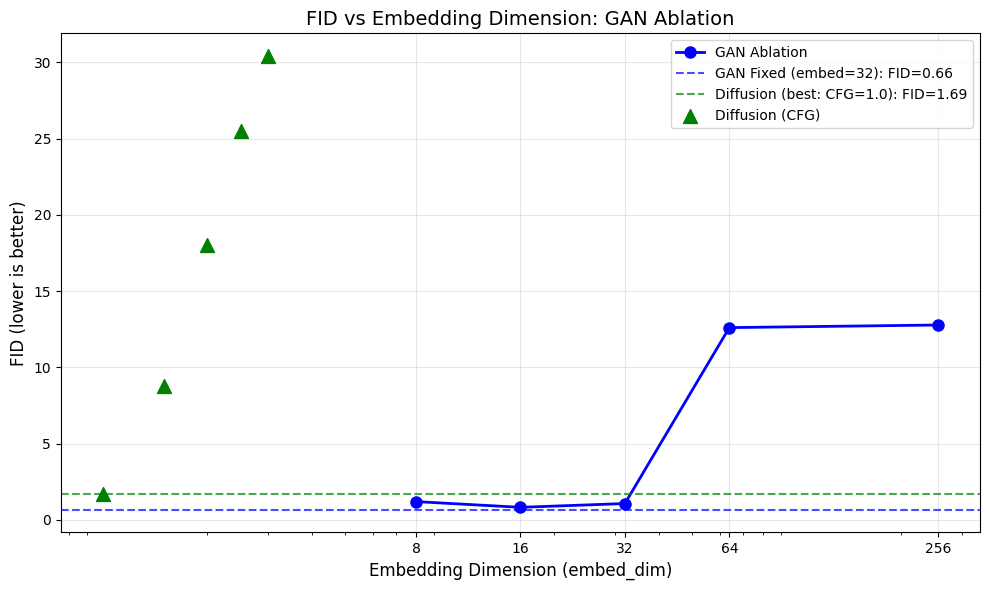

In [27]:
# Filter GAN ablation results
gan_ablation_df = df_results[df_results['Model'].str.contains('GAN \(embed', na=False)].copy()
gan_ablation_df['embed_dim'] = gan_ablation_df['embed_dim'].astype(int)

fig, ax = plt.subplots(figsize=(10, 6))

# Plot FID for GAN ablation
ax.plot(gan_ablation_df['embed_dim'], gan_ablation_df['FID'], 
        marker='o', linewidth=2, markersize=8, color='blue', label='GAN Ablation')

# Add GAN fixed as reference line
gan_fixed_fid = fid_results.get('GAN_fixed', None)
if gan_fixed_fid is not None:
    ax.axhline(y=gan_fixed_fid, color='blue', linestyle='--', alpha=0.7, 
               label=f"GAN Fixed (embed=32): FID={gan_fixed_fid:.2f}")

# Add Diffusion lines for different guidance scales
diffusion_metrics = [(scale, fid_results.get(f'diffusion_features_{scale}', np.nan)) 
                      for scale in GUIDANCE_SCALES]
diffusion_metrics = [(s, fid) for s, fid in diffusion_metrics if not np.isnan(fid)]

if diffusion_metrics:
    # Find best diffusion FID
    best_scale, best_fid = min(diffusion_metrics, key=lambda x: x[1])
    ax.axhline(y=best_fid, color='green', linestyle='--', alpha=0.7,
               label=f"Diffusion (best: CFG={best_scale}): FID={best_fid:.2f}")
    
    # Also plot individual points
    scales = [s for s, _ in diffusion_metrics]
    fids = [f for _, f in diffusion_metrics]
    ax.scatter(scales, fids, color='green', marker='^', s=100, zorder=5, label='Diffusion (CFG)')

ax.set_xlabel('Embedding Dimension (embed_dim)', fontsize=12)
ax.set_ylabel('FID (lower is better)', fontsize=12)
ax.set_title('FID vs Embedding Dimension: GAN Ablation', fontsize=14)
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_xscale('log')
ax.set_xticks(gan_ablation_df['embed_dim'])
ax.set_xticklabels(gan_ablation_df['embed_dim'])

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "fid_vs_embed_dim.png"), dpi=150)
plt.show()

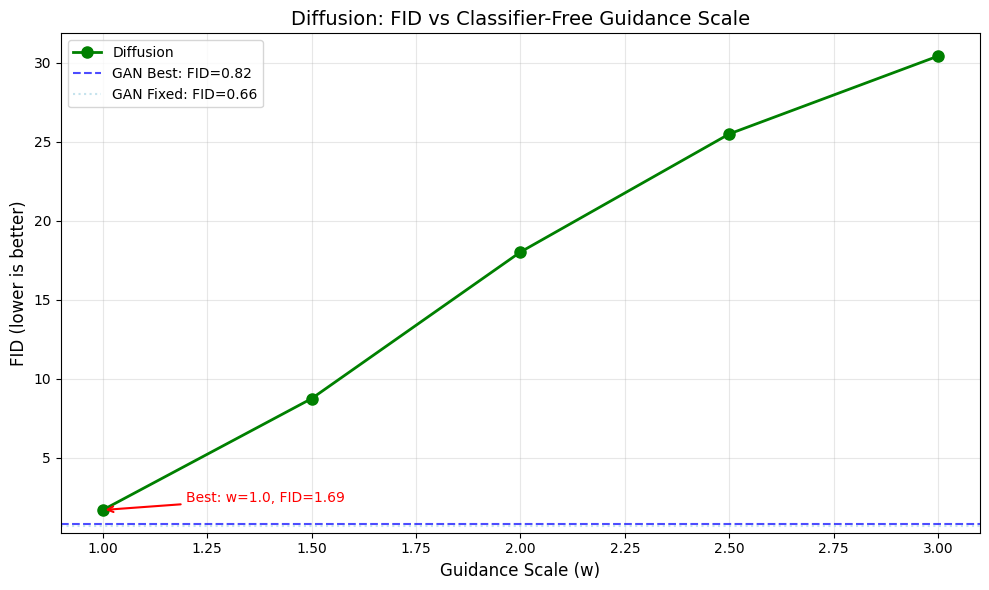

In [28]:
# Filter diffusion results
diffusion_df = df_results[df_results['Model'].str.contains('Diffusion', na=False)].copy()

if not diffusion_df.empty:
    fig, ax = plt.subplots(figsize=(10, 6))
    
    # Extract guidance scale from model name (e.g., "Diffusion (CFG=1.0)" -> 1.0)
    diffusion_df['guidance_scale'] = diffusion_df['Model'].str.extract(r'CFG=([0-9.]+)').astype(float)
    diffusion_df = diffusion_df.sort_values('guidance_scale')
    
    # Plot FID vs guidance scale
    ax.plot(diffusion_df['guidance_scale'], diffusion_df['FID'], 
            marker='o', linewidth=2, markersize=8, color='green', label='Diffusion')
    
    # Add best GAN as reference line
    gan_best_fid = min(fid_results.get(f'GAN_embed{ed}', np.inf) for ed in gan_ablation_data.keys())
    ax.axhline(y=gan_best_fid, color='blue', linestyle='--', alpha=0.7,
               label=f"GAN Best: FID={gan_best_fid:.2f}")
    
    # Add GAN fixed
    if gan_fixed_fid is not None:
        ax.axhline(y=gan_fixed_fid, color='lightblue', linestyle=':', alpha=0.7,
                   label=f"GAN Fixed: FID={gan_fixed_fid:.2f}")
    
    ax.set_xlabel('Guidance Scale (w)', fontsize=12)
    ax.set_ylabel('FID (lower is better)', fontsize=12)
    ax.set_title('Diffusion: FID vs Classifier-Free Guidance Scale', fontsize=14)
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # Annotate the best point
    best_idx = diffusion_df['FID'].idxmin()
    best_scale = diffusion_df.loc[best_idx, 'guidance_scale']
    best_fid = diffusion_df.loc[best_idx, 'FID']
    ax.annotate(f'Best: w={best_scale}, FID={best_fid:.2f}',
                xy=(best_scale, best_fid),
                xytext=(best_scale + 0.2, best_fid + 0.5),
                arrowprops=dict(arrowstyle='->', color='red', lw=1.5),
                fontsize=10, color='red')
    
    plt.tight_layout()
    plt.savefig(os.path.join(RESULTS_DIR, "diffusion_fid_vs_guidance.png"), dpi=150)
    plt.show()

### 6.7 Visualization: Conditional Accuracy by Model

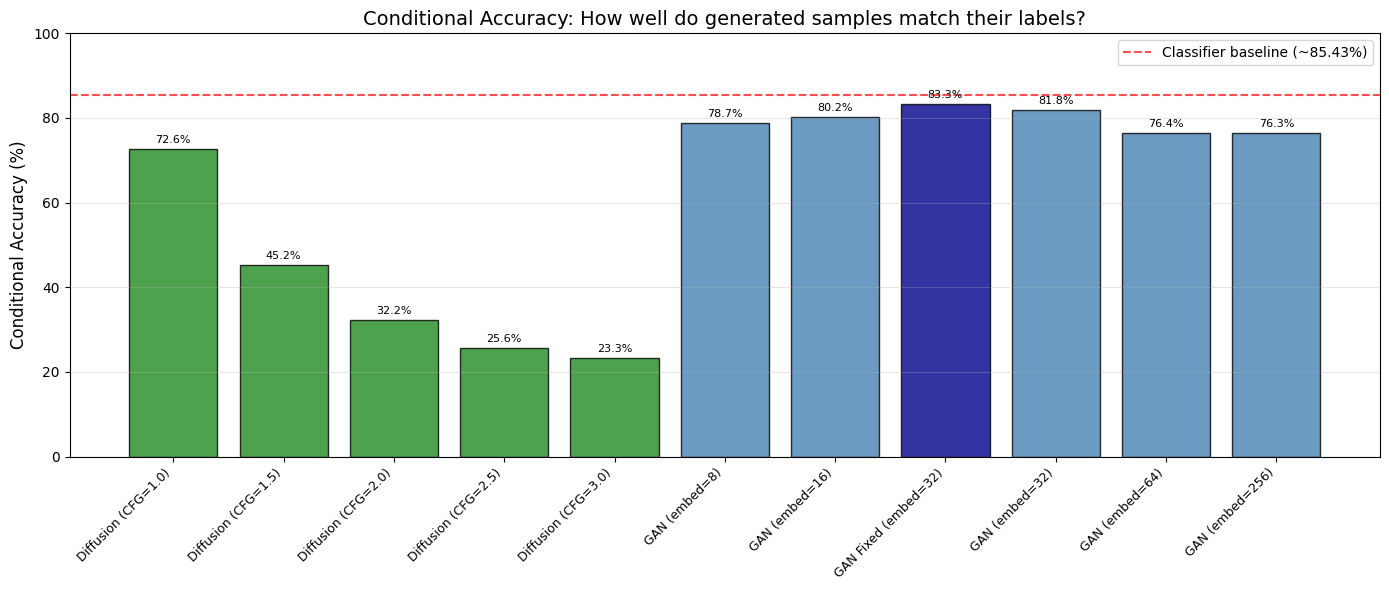

In [30]:
fig, ax = plt.subplots(figsize=(14, 6))

# Prepare data
models = df_results['Model'].tolist()
accuracies = df_results['Cond Acc (%)'].tolist()

# Color coding: GAN ablation in blue, GAN fixed in dark blue, Diffusion in green
colors = []
for model in models:
    if 'GAN (embed' in model:
        colors.append('steelblue')
    elif 'GAN Fixed' in model:
        colors.append('darkblue')
    elif 'Diffusion' in model:
        colors.append('forestgreen')
    else:
        colors.append('gray')

bars = ax.bar(range(len(models)), accuracies, color=colors, alpha=0.8, edgecolor='black')
ax.set_xticks(range(len(models)))
ax.set_xticklabels(models, rotation=45, ha='right', fontsize=9)
ax.set_ylabel('Conditional Accuracy (%)', fontsize=12)
ax.set_title('Conditional Accuracy: How well do generated samples match their labels?', fontsize=14)
ax.set_ylim(0, 100)
ax.axhline(y=85.43, color='red', linestyle='--', alpha=0.7, label='Classifier baseline (~85.43%)')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for bar, acc in zip(bars, accuracies):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f'{acc:.1f}%', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "conditional_accuracy.png"), dpi=150)
plt.show()